In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense
from datetime import date

In [3]:
start = '2012-01-01'
end = date.today().strftime("%Y-%m-%d")
stock =  "GOOG"

data = yf.download(stock,start,end)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3337 entries, 2012-01-03 to 2025-04-09
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   3337 non-null   float64
 1   (High, GOOG)    3337 non-null   float64
 2   (Low, GOOG)     3337 non-null   float64
 3   (Open, GOOG)    3337 non-null   float64
 4   (Volume, GOOG)  3337 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 156.4 KB


In [6]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2025-04-03,152.630005,154.686996,152.179993,152.835007,28416100
2025-04-04,147.740005,153.089996,147.539993,149.899994,39832200
2025-04-07,149.240005,154.929993,142.660004,143.389999,47823000
2025-04-08,146.580002,154.440002,145.210007,153.574997,35304400
2025-04-09,161.059998,161.869995,145.809998,146.330002,46413100


In [8]:
price = data.Close.values.reshape(-1,1)
price.shape

(3337, 1)

In [9]:
price

array([[ 16.49500084],
       [ 16.56614685],
       [ 16.33634949],
       ...,
       [149.24000549],
       [146.58000183],
       [161.05999756]])

In [16]:
scaler = MinMaxScaler(feature_range= (0,1))
prices_scaled = scaler.fit_transform(price)

In [17]:
prices_scaled

array([[0.01361764],
       [0.0139851 ],
       [0.01279822],
       ...,
       [0.69923011],
       [0.6854915 ],
       [0.76027899]])

In [18]:
window_size = 30
forecast_day = 7

In [ ]:
def create_dataset(data, window_size, forecast_day):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_day + 1):
        X.append(data[i:(i + window_size), 0]) 
        y.append(data[(i + window_size):(i + window_size + forecast_day), 0]) 
    return np.array(X), np.array(y)

In [24]:
x, y = create_dataset(prices_scaled, window_size,forecast_day)
print("Bentuk x:", x.shape)
print("Bentuk y:", y.shape)

Bentuk x: (3301, 30)
Bentuk y: (3301, 7)


In [25]:
x

array([[0.01361764, 0.0139851 , 0.01279822, ..., 0.00599965, 0.00680498,
        0.00649258],
       [0.0139851 , 0.01279822, 0.01164721, ..., 0.00680498, 0.00649258,
        0.00595483],
       [0.01279822, 0.01164721, 0.0081186 , ..., 0.00649258, 0.00595483,
        0.00607775],
       ...,
       [0.89769691, 0.89248632, 0.88696616, ..., 0.82086305, 0.79168149,
        0.77587696],
       [0.89248632, 0.88696616, 0.89382766, ..., 0.79168149, 0.77587696,
        0.73445457],
       [0.88696616, 0.89382766, 0.89129976, ..., 0.77587696, 0.73445457,
        0.73533259]])

In [27]:
x = x.reshape((x.shape[0],x.shape[1],1))
x.shape

(3301, 30, 1)

In [30]:
train_size = int(len(x) * 0.8)
X_train, y_train = x[:train_size], y[:train_size]
X_test, y_test = x[train_size:], y[train_size:]
print("Jumlah training samples:", X_train.shape[0])
print("Jumlah testing samples:", X_test.shape[0])

Jumlah training samples: 2640
Jumlah testing samples: 661


In [31]:
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(window_size, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(units=50))
model.add(Dense(units=forecast_day))

C:\Users\Acer\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 29, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,549 (91.99 KB)

 Trainable params: 23,549 (91.99 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0325 - val_loss: 0.0024
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8267e-04 - val_loss: 0.0031
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0427e-04 - val_loss: 0.0038
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3209e-04 - val_loss: 0.0035
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8855e-04 - val_loss: 0.0024
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1721e-04 - val_loss: 0.0024
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8201e-04 - val_loss: 0.0022
Epoch 8/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9100e-04 - val_loss: 0.0022
Epoch 9/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5944e-04 - val_loss: 0.0023
Epoch 10/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4960e-04 - val_loss: 0.0028
Epoch 11/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4976e-04 - val_loss: 0.0017
Epoch 12/100
83/83 ━━━━

In [34]:
predictions = model.predict(X_test)
print(predictions)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[0.5457159  0.5508904  0.5489382  ... 0.5537577  0.55342406 0.55812085]
 [0.549566   0.5546537  0.5526861  ... 0.55718917 0.55725014 0.5620379 ]
 [0.55587816 0.5606625  0.5583789  ... 0.56321555 0.5632854  0.5679238 ]
 ...
 [0.7943039  0.79314274 0.78859466 ... 0.7908564  0.7891513  0.79278374]
 [0.76980007 0.7729338  0.7709632  ... 0.77456874 0.7667996  0.77086526]
 [0.7515095  0.756676   0.75506    ... 0.75944084 0.75030714 0.7541009 ]]


In [35]:
predictions_denorm = scaler.inverse_transform(predictions)
y_test_denorm = scaler.inverse_transform(y_test)

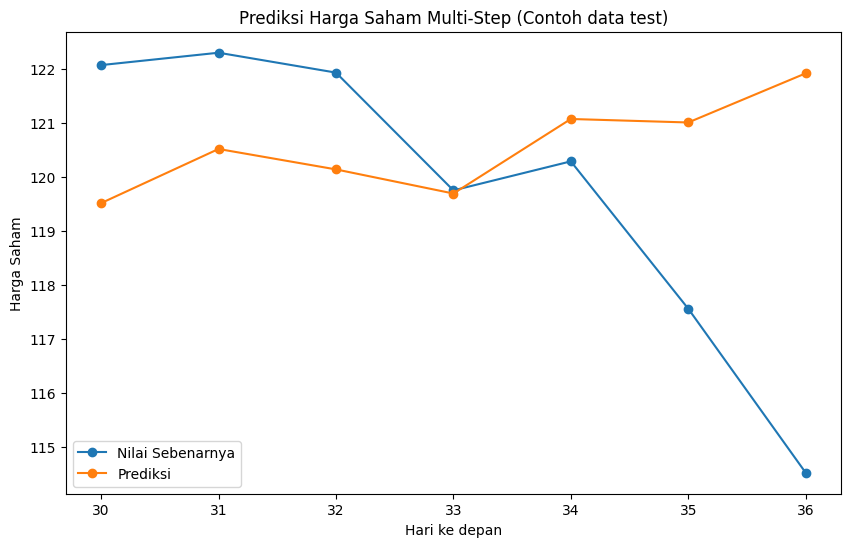

In [37]:
plt.figure(figsize=(10, 6))
# Visualisasi nilai asli dan prediksi
plt.plot(range(window_size, window_size + forecast_day), y_test_denorm[0],
         marker='o', label='Nilai Sebenarnya')
plt.plot(range(window_size, window_size + forecast_day), predictions_denorm[0],
         marker='o', label='Prediksi')
plt.title("Prediksi Harga Saham Multi-Step (Contoh data test)")
plt.xlabel("Hari ke depan")
plt.ylabel("Harga Saham")
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


C:\Users\Acer\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Data yang diambil dari yfinance:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.716064  72.776591  71.466805  71.721011  135480400
2020-01-03  72.009125  72.771752  71.783969  71.941336  146322800
2020-01-06  72.582901  72.621639  70.876068  71.127858  118387200
2020-01-07  72.241531  72.849208  72.021215  72.592578  108872000
2020-01-08  73.403641  73.706271  71.943751  71.943751  132079200
Bentuk X: (650, 100)
Bentuk y: (650, 7)
Jumlah training samples: 520
Jumlah testing samples: 130


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 99, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,549 (91.99 KB)

 Trainable params: 23,549 (91.99 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.3205 - val_loss: 0.0281
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0208 - val_loss: 0.0069
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0082 - val_loss: 0.0059
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0052 - val_loss: 0.0059
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0042 - val_loss: 0.0059
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - val_loss: 0.0057
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0040 - val_loss: 0.0056
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0035 - val_loss: 0.0055
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0041 - val_loss: 0.0053
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0035 - val_loss: 0.0055
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037 - val_loss: 0.0052
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

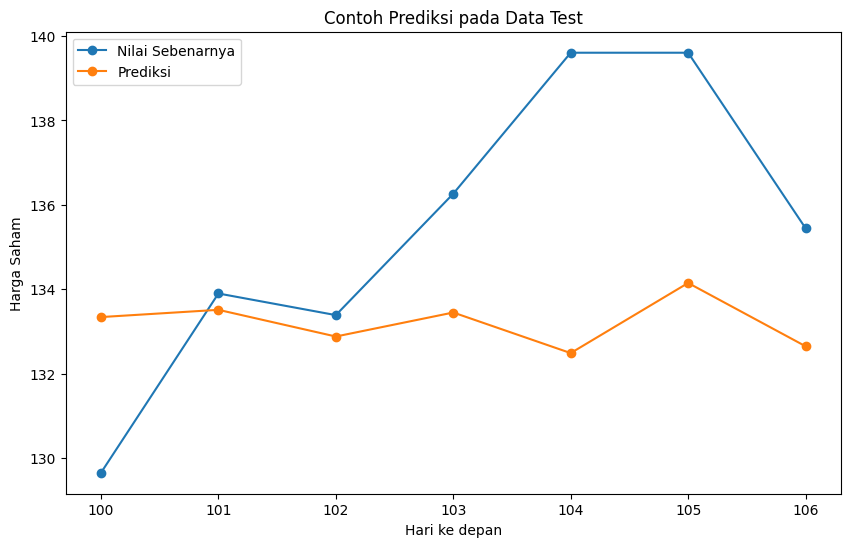

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediksi harga saham untuk 7 hari ke depan:
[[127.137146 126.82335  126.61233  127.65869  126.888245 128.23485
  127.59672 ]]


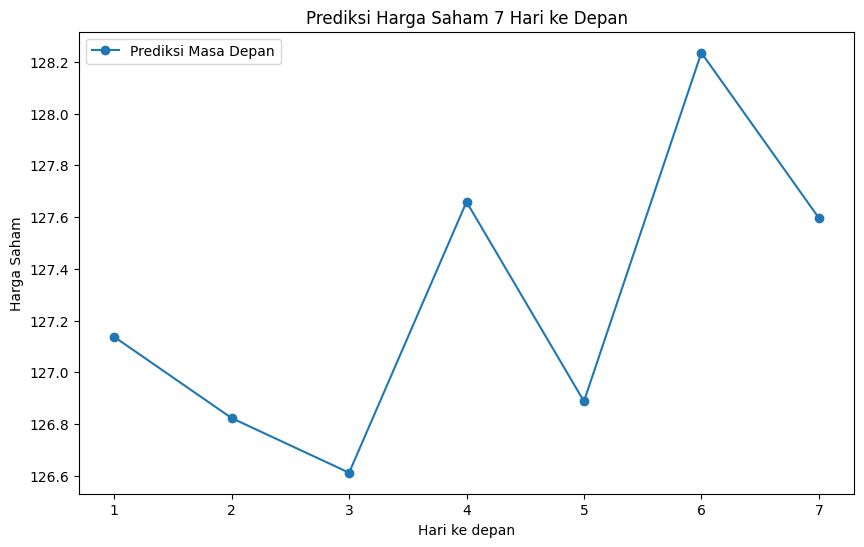

In [42]:
# 1. Impor library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense

# 2. Mengambil data harga saham dari yfinance
# Misalnya, kita menggunakan saham Apple (AAPL)
ticker = "AAPL"
start_date = "2020-01-01"
end_date   = "2022-12-31"
data = yf.download(ticker, start=start_date, end=end_date)
print("Data yang diambil dari yfinance:")
print(data.head())

# 3. Praproses Data: Normalisasi dan pembuatan dataset dengan teknik sliding window
# Kita menggunakan kolom 'Close' (harga penutupan)
prices = data['Close'].values.reshape(-1, 1)

# Normalisasi data ke rentang [0,1] agar pelatihan lebih stabil
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

# Tentukan panjang window (input sequence) dan forecast_horizon (jumlah hari yang ingin diprediksi)
window_size = 100      # Input: 30 hari historis
forecast_horizon = 7  # Target: memprediksi 7 hari ke depan

# Fungsi untuk membuat dataset (input X dan target y) dengan teknik sliding window
def create_dataset(data, window_size, forecast_horizon):
    X, y = [], []
    # Pastikan bahwa setiap input window diikuti oleh target sequence selama forecast_horizon hari
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:(i + window_size), 0])
        y.append(data[(i + window_size):(i + window_size + forecast_horizon), 0])
    return np.array(X), np.array(y)

# Buat dataset
X, y = create_dataset(prices_scaled, window_size, forecast_horizon)
print("Bentuk X:", X.shape)  # Misal: (jumlah_sample, window_size)
print("Bentuk y:", y.shape)  # Misal: (jumlah_sample, forecast_horizon)

# Ubah X agar berbentuk 3 dimensi: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# 4. Membagi data menjadi training dan testing
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test,  y_test  = X[train_size:], y[train_size:]
print("Jumlah training samples:", X_train.shape[0])
print("Jumlah testing samples:", X_test.shape[0])

# 5. Membangun Model CNN + LSTM untuk prediksi multi-step
model = Sequential()
# Layer Conv1D untuk ekstraksi fitur lokal
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(window_size, 1)))
# MaxPooling1D untuk reduksi dimensi
model.add(MaxPooling1D(pool_size=2))
# LSTM untuk menangkap informasi temporal
model.add(LSTM(units=50))
# Dense layer dengan unit sebanyak forecast_horizon (output: prediksi multi-hari sekaligus)
model.add(Dense(units=forecast_horizon))

# Kompilasi model dengan optimizer Adam dan loss MSE
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# 6. Melatih model
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

# 7. Evaluasi pada data test (optional) 
# Melakukan prediksi pada data test dan denormalisasi hasilnya
predictions = model.predict(X_test)
predictions_denorm = scaler.inverse_transform(predictions)
y_test_denorm = scaler.inverse_transform(y_test)

# Visualisasi contoh prediksi pada data test (misalnya sample pertama)
plt.figure(figsize=(10, 6))
plt.plot(range(window_size, window_size + forecast_horizon), y_test_denorm[0],
         marker='o', label='Nilai Sebenarnya')
plt.plot(range(window_size, window_size + forecast_horizon), predictions_denorm[0],
         marker='o', label='Prediksi')
plt.title("Contoh Prediksi pada Data Test")
plt.xlabel("Hari ke depan")
plt.ylabel("Harga Saham")
plt.legend()
plt.show()

# 8. Memprediksi Harga Saham di Masa Depan
# Di sini, kita ambil window terakhir dari data historis yang ada dan prediksi ke depan
last_window = prices_scaled[-window_size:]      # Ambil 30 hari terakhir
last_window = last_window.reshape(1, window_size, 1)  # Ubah bentuk agar sesuai dengan input model

# Prediksi harga saham untuk forecast_horizon hari ke depan
future_prediction = model.predict(last_window)
future_prediction_denorm = scaler.inverse_transform(future_prediction)

print("Prediksi harga saham untuk {} hari ke depan:".format(forecast_horizon))
print(future_prediction_denorm)

# Visualisasi prediksi masa depan
plt.figure(figsize=(10, 6))
plt.plot(range(1, forecast_horizon + 1), future_prediction_denorm[0],
         marker='o', label='Prediksi Masa Depan')
plt.title("Prediksi Harga Saham {} Hari ke Depan".format(forecast_horizon))
plt.xlabel("Hari ke depan")
plt.ylabel("Harga Saham")
plt.legend()
plt.show()
